<a href="https://colab.research.google.com/github/uxntani/AI-LAB/blob/main/2026_09_11_Lab1_Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jug A capacity = 4L, Jug B capacity = 3L, target = 2L

Minimum number of operations: 4

Step | Operation        | State (A, B)
-----+------------------+-------------
  0  | Start            | (0, 0)
  1  | Fill Jug B       | (0, 3)
  2  | Pour B into A    | (3, 0)
  3  | Fill Jug B       | (3, 3)
  4  | Pour B into A    | (4, 2)


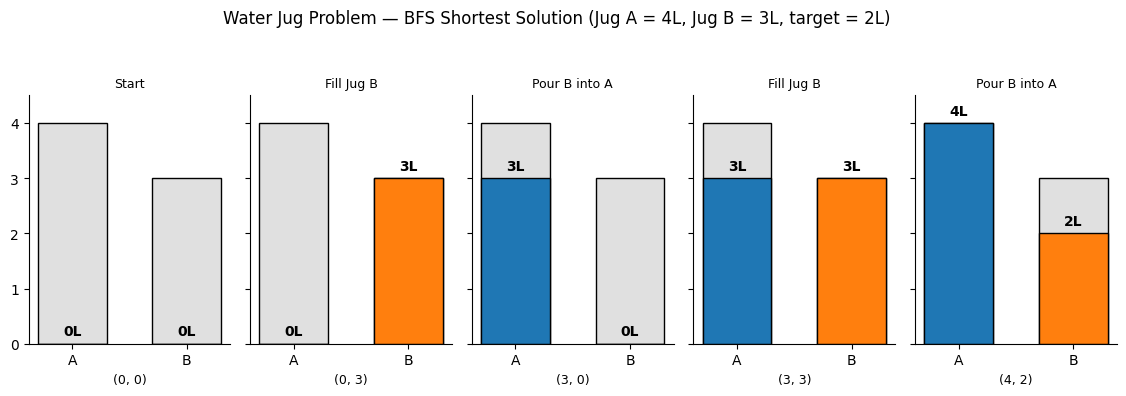

In [1]:
from collections import deque
import matplotlib.pyplot as plt

CAP_A, CAP_B = 4, 3
START = (0, 0)

def is_goal(state):
    return state[0] == 2 or state[1] == 2

def next_states(state):
    a, b = state
    moves = []

    moves.append(((CAP_A, b), "Fill Jug A"))
    moves.append(((a, CAP_B), "Fill Jug B"))
    moves.append(((0, b), "Empty Jug A"))
    moves.append(((a, 0), "Empty Jug B"))

    pour = min(a, CAP_B - b)
    moves.append(((a - pour, b + pour), "Pour A into B"))

    pour = min(b, CAP_A - a)
    moves.append(((a + pour, b - pour), "Pour B into A"))

    return [(s, d) for s, d in moves if s != state]

def bfs_water_jug():
    visited = {START}
    parent = {START: None}
    queue = deque([START])

    if is_goal(START):
        return [(START, "Start")]

    while queue:
        state = queue.popleft()
        for nxt, desc in next_states(state):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = (state, desc)
                if is_goal(nxt):
                    path = [(nxt, desc)]
                    cur = state
                    while cur is not None:
                        prev, d = parent[cur] if parent[cur] else (None, "Start")
                        path.append((cur, d if prev is not None else "Start"))
                        cur = prev
                    path.reverse()
                    return path
                queue.append(nxt)
    return None

def draw_solution(path, filename="water_jug_solution.png"):
    """Draw one panel per step: two bars showing how full each jug is."""
    n = len(path)
    fig, axes = plt.subplots(1, n, figsize=(2.3 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (state, desc) in zip(axes, path):
        a, b = state
        ax.bar(["A", "B"], [CAP_A, CAP_B], color="#e0e0e0", edgecolor="black", width=0.6)
        ax.bar(["A", "B"], [a, b], color=["#1f77b4", "#ff7f0e"], edgecolor="black", width=0.6)
        ax.set_ylim(0, max(CAP_A, CAP_B) + 0.5)
        ax.text(0, a + 0.15, f"{a}L", ha="center", fontweight="bold")
        ax.text(1, b + 0.15, f"{b}L", ha="center", fontweight="bold")
        ax.set_title(desc, fontsize=9)
        ax.set_xlabel(f"({a}, {b})", fontsize=9)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    fig.suptitle("Water Jug Problem — BFS Shortest Solution "
                  f"(Jug A = {CAP_A}L, Jug B = {CAP_B}L, target = 2L)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(filename, dpi=150)
    return fig

if __name__ == "__main__":
    solution = bfs_water_jug()

    print(f"Jug A capacity = {CAP_A}L, Jug B capacity = {CAP_B}L, target = 2L\n")
    print("Minimum number of operations:", len(solution) - 1)
    print("\nStep | Operation        | State (A, B)")
    print("-----+------------------+-------------")
    for i, (state, desc) in enumerate(solution):
        print(f" {i:2d}  | {desc:<16} | {state}")

    draw_solution(solution)
    plt.show()
